# 4 &middot; Elastostatics as a Minimization Problem

Posing an elastic object is an **optimization**: find the vertex positions $x$
that minimize

$$
E(x) = \underbrace{E_{\text{elastic}}(x)}_{\text{wants rest shape}}
     + \underbrace{\tfrac{K}{2}\lVert x_{\text{pin}} - p\rVert^2}_{\text{hold pins}}
     + \underbrace{\tfrac{K}{2}\lVert x_{\text{handle}} - h\rVert^2}_{\text{drag handle}}.
$$

We pin part of the shape, drag a **handle**, and let everything else settle. The
pin and handle terms are quadratic *spring* penalties. We minimize silently with
Newton (the solver is tutorial 5's job) and focus on how **different energies
pose differently**.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import simkit
from simkit.solvers import newton_solver
import utils

## A small, readable simulator

`ElasticPose` is our first simulator class. It composes three energy terms from
`utils` &mdash; the elastic material, a fixed **pin** spring, and a movable
**handle** spring &mdash; and exposes `energy / gradient / hessian` that sum
those terms **one per line**, exactly as the Newton solver wants them. Every
later tutorial builds its simulator the same way.

In [2]:
class ElasticPose:
    """Minimize  elastic(x) + pin spring + handle spring  with Newton."""

    def __init__(self, X, T, material="Neo-Hookean", K=1e5):
        self.p   = utils.precompute(X, T, mu=1.0, lam=1.0)   # J, vol, masses, ...
        self.psi = utils.make_material(material)             # elastic term
        self.pin    = utils.PenaltySpring(self.p.n, self.p.dim, K)
        self.handle = utils.PenaltySpring(self.p.n, self.p.dim, K)

    def set_pin(self, idx, targets):    self.pin.set(idx, targets);    return self
    def set_handle(self, idx, targets): self.handle.set(idx, targets); return self

    def energy(self, x):
        E_elastic = self.psi.energy(x, self.p)
        E_pin     = self.pin.energy(x)
        E_handle  = self.handle.energy(x)
        return E_elastic + E_pin + E_handle

    def gradient(self, x):
        g_elastic = self.psi.gradient(x, self.p)
        g_pin     = self.pin.gradient(x)
        g_handle  = self.handle.gradient(x)
        return g_elastic + g_pin + g_handle

    def hessian(self, x):
        H_elastic = self.psi.hessian(x, self.p)
        H_pin     = self.pin.hessian(x)
        H_handle  = self.handle.hessian(x)
        return H_elastic + H_pin + H_handle

    def solve(self, U0, iters=30):
        x = newton_solver(U0.reshape(-1, 1), self.energy, self.gradient, self.hessian,
                          max_iter=iters, do_line_search=True)
        return x.reshape(self.p.n, self.p.dim)

## A triangle: pin the left vertex, swing the right one in a figure-8

The pinned vertex stays put while the handle traces a **figure-8** (a
lemniscate), so the free apex both stretches and compresses. We step the pose
explicitly: at each handle position we re-aim the handle and re-solve, starting
each solve from the previous equilibrium.

In [3]:
X = np.array([[-0.5, 0.0], [0.5, 0.0], [0.0, np.sqrt(3) / 2]])
T = np.array([[0, 1, 2]])
PIN, HANDLE = 0, 1

# figure-8 (lemniscate) traced by the handle, starting from rest (t=0 -> no offset)
t = np.linspace(0, 2 * np.pi, 48)
handle_path = X[HANDLE] + np.stack([0.45 * np.sin(t), 0.6 * np.sin(2 * t)], axis=1)

pose = ElasticPose(X, T, "Neo-Hookean").set_pin(PIN, X[PIN])
states = []
U = X.copy()
for h in handle_path:
    pose.set_handle(HANDLE, h)
    U = pose.solve(U)
    states.append(U.copy())

fig, anim = utils.animate_mesh(states, T, lims=((-1.2, 1.6), (-1.2, 1.2)),
    title="Neo-Hookean triangle: handle traces a figure-8",
    pin_pts=X[[PIN]], handle_traj=[s[HANDLE] for s in states],
    target_pts=list(handle_path), fps=20, figsize=(6, 5))
utils.show_video(fig, anim, "media/04_triangle.mp4", fps=20)

## Same handle, three energies, very different poses

Pull the handle far up-and-right and compare where the free apex lands under each
model. Linear elasticity (no rotation-invariance) reacts quite differently from
ARAP and Neo-Hookean. We loop over the three materials explicitly, building a
fresh `ElasticPose` for each.

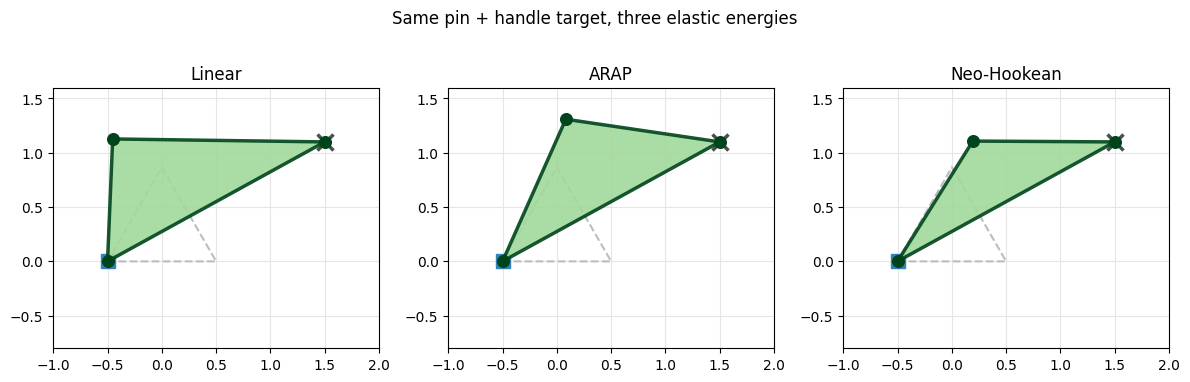

In [4]:
target = np.array([1.5, 1.1])
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, material in zip(axes, ["Linear", "ARAP", "Neo-Hookean"]):
    pose = ElasticPose(X, T, material).set_pin(PIN, X[PIN]).set_handle(HANDLE, target)
    U = pose.solve(X.copy())
    utils.setup_axes(ax, (-1.0, 2.0), (-0.8, 1.6), title=material)
    utils.TriangleArtist(ax, U, rest=X)
    ax.plot(*X[PIN], "s", color=utils.PIN_C, ms=10)
    ax.plot(*target, "x", color="0.3", ms=12, mew=2.5)
fig.suptitle("Same pin + handle target, three elastic energies")
fig.tight_layout(); plt.show()

## A cantilever beam: pin the left edge, swing the whole right edge

The handle is now **every vertex on the right edge** (not one). We **rotate those
target points about the origin** &mdash; the orange handles swing up and down in a
wide arc &mdash; which whips the beam through large bends. Starting from rest, the
angle sweeps to about $\pm 120^\circ$ and back. Targets are marked with an
&times;.

In [5]:
Xb, Tb = utils.triangulated_grid(nx=16, ny=5, width=2.0, height=0.4)
pin_idx   = np.where(Xb[:, 0] <= Xb[:, 0].min() + 1e-6)[0]
right_idx = np.where(Xb[:, 0] >= Xb[:, 0].max() - 1e-6)[0]

def rotate_about_origin(P, theta):
    R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
    return P @ R.T

# angle swings +/-120 deg from rest and back
angles = np.deg2rad(120) * np.sin(np.linspace(0, 2 * np.pi, 48))

beam = ElasticPose(Xb, Tb, "Neo-Hookean").set_pin(pin_idx, Xb[pin_idx])
states, targets = [], []
U = Xb.copy()
for th in angles:
    tgt = rotate_about_origin(Xb[right_idx], th)
    beam.set_handle(right_idx, tgt)
    U = beam.solve(U)
    states.append(U.copy())
    targets.append(tgt.copy())

fig, anim = utils.animate_mesh(states, Tb, lims=((-1.8, 1.8), (-1.8, 1.8)),
    title="Cantilever: right edge swung in an arc about the origin",
    pin_pts=Xb[pin_idx], handle_traj=[s[right_idx] for s in states],
    target_pts=targets, fps=20, figsize=(6, 6))
utils.show_video(fig, anim, "media/04_beam.mp4", fps=20)

### Takeaways
* Posing = **minimizing** elastic energy + soft pin/handle springs.
* The *same* setup with a *different* energy gives a *different* equilibrium.
* We solved it silently with Newton. **How** that solve works is next.